<a href="https://colab.research.google.com/github/sinnu2004/MLProjects/blob/main/LinearRegressionPipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("/content/train.csv")

In [3]:
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [4]:
df = df.drop(columns=['PassengerId','Name','Ticket','Fare','Cabin'])

In [5]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Embarked,2


In [6]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [7]:
df['Age'].isnull().sum()

np.int64(0)

In [8]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [9]:
df.head(1)

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S


In [10]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [11]:
numerical_column = x.select_dtypes(include=np.number).columns
categorical_column = x.select_dtypes(exclude=np.number).columns

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
numerical_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
categorical_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

In [14]:
processor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline,numerical_column),
    ('cat', categorical_pipeline,categorical_column)
])

In [15]:
model = Pipeline(steps=[
    ('Preprocessor',processor),
    ('regressor',LinearRegression())
])

In [16]:
model.fit(X_train,Y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Sex', 'Embarked'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [17]:
y_predict = model.predict(X_test)

In [18]:
y_predict

array([ 0.12164048,  0.25526923,  0.14168281,  0.87416545,  0.72818915,
        0.96061587,  0.66282737,  0.08747818,  0.72884876,  0.96187457,
        0.3562115 ,  0.02601745,  0.48312717,  0.17317002,  0.23117228,
        0.99257125,  0.33211455,  0.66282737,  0.27454678,  0.34475869,
        0.12240525,  0.40741076,  0.62441109,  0.14168281,  0.09493898,
        0.0471764 ,  0.45817553,  0.25526923,  0.07609274,  0.6033195 ,
        0.1465022 ,  0.64669401,  0.5078195 ,  0.60958896,  0.15132159,
        0.1508871 ,  0.4363271 ,  0.66282737,  1.02101942,  0.09493898,
        0.22998094,  0.06156721,  0.09493898,  0.14817739,  0.59929064,
        0.07550374,  0.1465022 ,  0.12722464,  0.12240525,  0.33894949,
        0.71858405,  0.78233213, -0.05640013,  0.44903861, -0.02195133,
        0.96669396,  0.25044984,  0.90839311,  0.75064165,  0.71439059,
        0.13686342,  0.84042972,  0.74763629,  0.42813839,  0.14817739,
        0.64461508,  0.30346312,  0.0983083 ,  0.18284248,  0.87

In [21]:
training = model.score(X_train,Y_train)
testing = model.score(X_test,Y_test)

In [24]:
print("Training Accuracy:",training*100)
print("Testing Accuracy:",testing*100)

Training Accuracy: 38.36355239667433
Testing Accuracy: 44.425740982622756


In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [26]:
print("MSE:", mean_squared_error(Y_test, y_predict))
print("MAE:", mean_absolute_error(Y_test, y_predict))
print("R2 Score:", r2_score(Y_test, y_predict))

MSE: 0.13476857543928752
MAE: 0.28471287897732245
R2 Score: 0.4442574098262275


In [29]:
print("Slope :", model.named_steps['regressor'].coef_)
print("Intercept :", model.named_steps['regressor'].intercept_)

Slope : [-0.13727899 -0.0625818  -0.04319201 -0.0128465   0.25732499 -0.25732499
  0.0353746   0.0089319  -0.04430651]
Intercept : 0.482469013456716


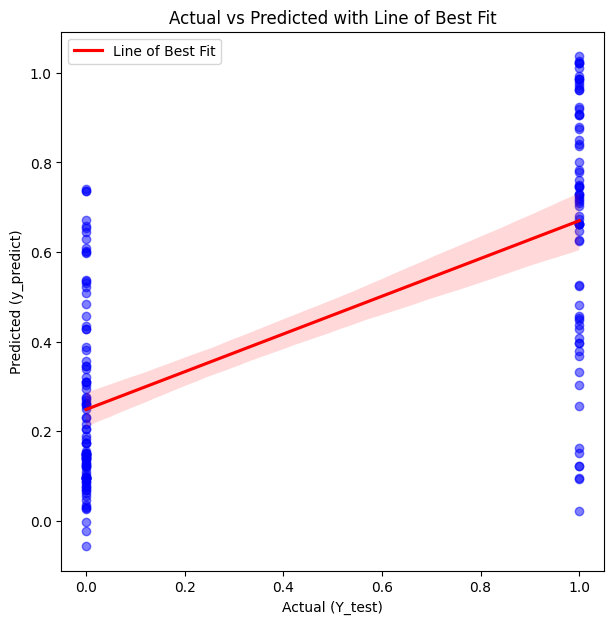

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
# Plot the data points and the line of best fit (regression line)
sns.regplot(x=Y_test, y=y_predict, scatter_kws={'alpha':0.5, 'color':'blue'}, line_kws={'color':'red', 'label':'Line of Best Fit'})

plt.xlabel('Actual (Y_test)')
plt.ylabel('Predicted (y_predict)')
plt.title('Actual vs Predicted with Line of Best Fit')
plt.legend()
plt.show()